In [23]:
library(tidyverse)

In [2]:
hplc_bbrs <- read.csv("BCO-DMO/hplc_bbrs.csv", na.strings="nd")
hplc_mote <- read.csv("BCO-DMO/hplc_mote.csv", na.strings="nd")
hplc_hpl <- read.csv("BCO-DMO/hplc_hpl.csv", na.strings="nd")
hplc_ngsfc <- read.csv("BCO-DMO/hplc_ngsfc.csv", na.strings="nd")

In [3]:
hplc_bbrs$source <- "BBRS"
hplc_mote$source  <- "MOTE"
hplc_hpl$source  <- "HPL"
hplc_ngsfc$source  <- "NGSFC"

In [4]:
pigments = c("Pras","Lut","Fuco","Perid","Allo","But_fuco","Hex_fuco","Zea","Tot_Chl_b", "DP", "Tot_Chl_a", "TChl", "Chl_c1c2", "Chl_c3")
data = c("Date", "depth", "source")
fulldat = c(pigments, data)

In [5]:
names(hplc_bbrs)

[1] "Cruise_ID1"       "Cruise_ID2"       "Cruise_number"    "leg"             
 [5] "cast"             "Date"             "Analyzed_by"      "lon_n"           
 [9] "lat_n"            "lon"              "lat"              "year"            
[13] "month"            "day"              "depth_bottom"     "Date_time_local" 
[17] "time_start_local" "time_end_local"   "time_start_UTC"   "time_end_UTC"    
[21] "Date_time_UTC"    "sample_number"    "depth"            "Tot_Chl_a"       
[25] "Tot_Chl_b"        "Tot_Chl_c"        "alpha_beta_Car"   "alpha_Car"       
[29] "beta_Car"         "But_fuco"         "Hex_fuco"         "Allo"            
[33] "Diadino"          "Diato"            "Fuco"             "Perid"           
[37] "Zea"              "MV_Chl_a"         "DV_Chl_a"         "Chlide_a"        
[41] "Chl_a_allom"      "Chl_a_prime"      "MV_Chl_b"         "DV_Chl_b"        
[45] "Chl_c1"           "Chl_c2"           "Chl_c1c2"         "Chl_c3"          
[49] "Lut"              "Neo"              "Viola"            "Phytin_a"        
[53] "Phide_a"          "Pras"             "Anth"             "Gyro"            
[57] "TChl"             "PPC"              "PSC"              "PSP"             
[61] "Tcar"             "Tacc"             "Tpg"              "DP"              
[65] "Tacc_TChla"       "PSC_Tcar"         "PPC_Tcar"         "TChl_Tcar"       
[69] "PPC_Tpg"          "PSP_Tpg"          "TChla_Tpg"        "mPF"             
[73] "nPF"              "pPF"              "Fluor_Chl_a"      "Fluor_Phaeo"     
[77] "Comments"         "source"

In [6]:
HPLC_ds = rbind(hplc_bbrs[fulldat],
                hplc_mote[fulldat],
                hplc_hpl[fulldat],
                hplc_ngsfc[fulldat]) 

In [7]:
HPLC_ds$date <- as.Date(as.character(HPLC_ds$Date), format="%Y%m%d")
HPLC_ds <- HPLC_ds %>% select(-Date)

In [8]:
# set -9999 values to NA
HPLC_ds[pigments][HPLC_ds[pigments]<0] <- NA

In [9]:
# import interpolation functions
source('interpolateData.r')

Lade nötiges Paket: gsw



In [10]:
str(HPLC_ds)

'data.frame':	1598 obs. of  17 variables:
 $ Pras     : num  0.003 0.004 0.003 0.015 0.002 NA NA NA 0.011 0.009 ...
 $ Lut      : num  NA NA NA NA NA NA NA NA NA NA ...
 $ Fuco     : num  0.008 0.009 0.008 0.065 0.034 0.009 0.007 0.002 0.694 0.599 ...
 $ Perid    : num  0.005 0.006 0.01 0.008 0.009 NA 0.002 NA 0.08 0.164 ...
 $ Allo     : num  NA 0.001 0.001 0.006 0.002 NA NA NA 0.004 0.005 ...
 $ But_fuco : num  0.002 0.002 0.003 0.021 0.01 0.003 0.004 NA 0.002 0.016 ...
 $ Hex_fuco : num  0.008 0.01 0.011 0.086 0.042 0.011 0.013 0.003 0.034 0.032 ...
 $ Zea      : num  0.004 0.008 0.008 0.024 0.012 0.005 0.004 0.001 0.008 0.008 ...
 $ Tot_Chl_b: num  0.018 0.025 0.032 0.141 0.107 0.053 0.032 0.005 0.087 0.084 ...
 $ DP       : num  NA NA NA NA NA NA NA NA NA NA ...
 $ Tot_Chl_a: num  0.107 0.139 0.163 0.408 0.241 ...
 $ TChl     : num  NA NA NA NA NA NA NA NA NA NA ...
 $ Chl_c1c2 : num  0.004 0.002 0.004 0.021 0.011 0.002 0.001 NA 0.211 0.201 ...
 $ Chl_c3   : num  NA NA NA 0.014 0.

In [11]:
hplc_temp_store = list()

for (variable in pigments) {
    # interpolation algorithm: oce-rr
    hplc_temp_store[[variable]] <- interpolateData(HPLC_ds, variable, noofNA=70)
    names(hplc_temp_store[[variable]])[1] <- variable
    #hplc_temp_store[[variable]]$source <- variable
}

hplc_ds_cleaned <- hplc_temp_store %>% 
    reduce(full_join, by = "date")

In [12]:
justdateandsource <- unique(HPLC_ds %>% select(date, source))
hplc_ds_cleaned_source <- left_join(justdateandsource, hplc_ds_cleaned, by = "date")

Lade nötiges Paket: cowplot


Attache Paket: ‘cowplot’


Das folgende Objekt ist maskiert ‘package:lubridate’:

    stamp


Warning message:
“Removed 170 rows containing missing values or values outside the scale range (`geom_point()`).”


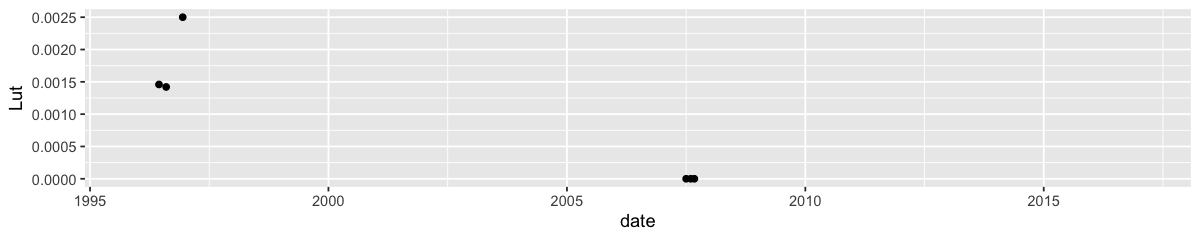

In [13]:
require(cowplot)
options(repr.plot.width=10, repr.plot.height=2)

ggplot(data=hplc_ds_cleaned_source)+geom_point(aes(x=date,y=Lut))

In [14]:
str(hplc_ds_cleaned_source)

'data.frame':	176 obs. of  16 variables:
 $ date     : Date, format: "1995-12-13" "1996-01-12" ...
 $ source   : chr  "BBRS" "BBRS" "BBRS" "BBRS" ...
 $ Pras     : num  0.00467 0.00698 NA NA NA ...
 $ Lut      : num  NA NA NA NA NA ...
 $ Fuco     : num  0.0154 0.2567 0.2122 0.2912 1.2477 ...
 $ Perid    : num  0.00482 0.05636 0.01284 0.04261 0.03304 ...
 $ Allo     : num  NA 0.00432 0.00489 0.00669 NA ...
 $ But_fuco : num  0.00642 0.00851 0.00381 0.00158 0.03133 ...
 $ Hex_fuco : num  0.0199 0.0198 0.0221 0.0184 0.2189 ...
 $ Zea      : num  0.00697 0.00565 0.00578 0.0071 0.0166 ...
 $ Tot_Chl_b: num  0.0497 0.0519 0.0375 0.0248 0.0849 ...
 $ DP       : num  NA NA NA NA NA NA NA NA NA NA ...
 $ Tot_Chl_a: num  0.127 0.434 0.278 0.28 2.243 ...
 $ TChl     : num  NA NA NA NA NA NA NA NA NA NA ...
 $ Chl_c1c2 : num  0.006 0.0959 0.0338 0.1235 0.0723 ...
 $ Chl_c3   : num  NA 0.04015 0.00811 NA 0.01714 ...


In [15]:
hplc_ds_cleaned_source$date


[1] "1995-12-13" "1996-01-12" "1996-02-13" "1996-03-13" "1996-04-16"
  [6] "1996-05-09" "1996-06-12" "1996-07-10" "1996-08-06" "1996-09-10"
 [11] "1996-10-09" "1996-11-10" "1996-12-11" "1997-01-07" "1997-02-14"
 [16] "1997-02-23" "1997-03-13" "1997-04-15" "1997-05-10" "1997-06-17"
 [21] "1997-07-08" "1997-07-16" "1997-08-17" "1997-09-17" "1997-10-14"
 [26] "1997-11-13" "1997-12-17" "1998-01-14" "1998-02-11" "1998-03-12"
 [31] "1998-04-21" "1998-06-09" "1998-07-09" "1998-08-05" "1998-09-01"
 [36] "1998-10-14" "1998-11-10" "1998-12-16" "1999-01-12" "1999-02-10"
 [41] "1999-03-04" "1999-04-07" "1999-05-06" "1999-06-08" "1999-07-15"
 [46] "1999-08-11" "1999-09-14" "1999-10-05" "1999-11-04" "1999-12-07"
 [51] "2000-01-11" "2000-02-08" "2000-03-09" "2000-04-11" "2000-05-11"
 [56] "2000-06-06" "2000-07-07" "2000-08-09" "2000-09-12" "2000-10-10"
 [61] "2000-11-03" "2000-12-05" "2001-01-11" "2001-02-18" "2001-03-14"
 [66] "2001-04-04" "2001-05-05" "2001-06-10" "2001-07-10" "2006-07-04"
 [71] "2006-08-03" "2006-09-12" "2006-10-10" "2006-11-02" "2006-12-05"
 [76] "2007-02-05" "2007-03-06" "2007-04-10" "2007-05-08" "2007-06-05"
 [81] "2007-07-03" "2007-08-07" "2007-09-04" "2007-10-19" "2007-12-11"
 [86] "2008-01-10" "2008-02-12" "2008-03-11" "2008-04-08" "2008-05-04"
 [91] "2008-06-03" "2008-07-08" "2008-08-05" "2008-09-10" "2008-10-10"
 [96] "2008-11-18" "2008-12-10" "2009-01-13" "2009-02-10" "2009-03-03"
[101] "2009-04-07" "2009-05-08" "2009-06-02" "2009-07-14" "2009-08-11"
[106] "2009-09-15" "2009-10-07" "2009-11-10" "2009-12-08" "2010-01-07"
[111] "2010-02-11" "2010-03-09" "2010-04-07" "2010-05-11" "2010-06-08"
[116] "2010-08-04" "2010-09-15" "2010-10-05" "2010-11-09" "2010-12-08"
[121] "2011-01-11" "2011-02-08" "2011-03-15" "2011-04-12" "2011-05-10"
[126] "2011-06-09" "2011-07-07" "2011-08-09" "2011-09-06" "2011-10-04"
[131] "2011-11-18" "2012-01-10" "2012-02-07" "2012-03-16" "2012-04-10"
[136] "2012-05-15" "2012-07-26" "2012-08-14" "2012-09-11" "2012-10-10"
[141] "2012-11-08" "2012-12-04" "2013-03-05" "2013-04-09" "2013-05-09"
[146] "2013-06-11" "2013-07-11" "2013-08-13" "2013-09-11" "2013-10-08"
[151] "2013-11-13" "2013-12-04" "2014-01-14" "2014-02-04" "2014-04-01"
[156] "2014-05-06" "2014-06-13" "2014-09-03" "2014-10-07" "2014-11-12"
[161] "2014-12-09" "2015-02-15" "2015-03-10" "2015-04-14" "2015-07-29"
[166] "2015-08-17" "2015-09-10" "2015-11-16" "2015-12-09" "2016-01-12"
[171] "2016-02-04" "2016-05-10" "2016-06-07" "2016-09-20" "2016-12-21"
[176] "2017-01-12"

In [16]:
# find duplicate monthly measurements
hplc_ds_cleaned_source_check <- hplc_ds_cleaned_source
hplc_ds_cleaned_source_check$time_month = format(hplc_ds_cleaned_source_check$date, format="%m-%Y")

hplc_ds_cleaned_source_check %>%
  summarise(n = n(), .by = time_month) %>%
  filter(n > 1L)

time_month,n
<chr>,<int>
02-1997,2
07-1997,2


In [17]:
hplc_ds_cleaned_source_check[hplc_ds_cleaned_source_check$date>as.Date("1997-07-01") & hplc_ds_cleaned_source_check$date<as.Date("1997-08-31"),]

,date,source,Pras,Lut,Fuco,Perid,Allo,But_fuco,Hex_fuco,Zea,Tot_Chl_b,DP,Tot_Chl_a,TChl,Chl_c1c2,Chl_c3,time_month
,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
21,1997-07-08,BBRS,NA,NA,0.05850336,NA,NA,0.004246589,0.01724486,NA,0.04089971,NA,0.1270224,NA,NA,NA,07-1997
22,1997-07-16,BBRS,0.01375016,NA,0.11476994,0.01965283,NA,0.009165537,0.02882325,0.005201272,0.06398878,NA,0.2481347,NA,0.12482703,0.012394782,07-1997
23,1997-08-17,BBRS,0.01070474,NA,0.02858898,0.00826501,NA,0.015272687,0.05013638,0.024483358,0.23289471,NA,0.2422212,NA,0.05769498,0.006563108,08-1997


In [18]:
# summarize duplicate monthly measurement in February and July 1997
duplicate1 = subset(hplc_ds_cleaned_source, date==as.Date("1997-02-23") | date==as.Date("1997-02-14"))
duplicate2 = subset(hplc_ds_cleaned_source, date==as.Date("1997-07-08") | date==as.Date("1997-07-16"))
meandup1 <- duplicate1 %>% summarize(across(where(is.numeric), mean, na.rm=TRUE), source="BBRS", date=mean(date))
meandup2 <- duplicate2 %>% summarize(across(where(is.numeric), mean, na.rm=TRUE), source="BBRS", date=mean(date))

hplc_ds_cleaned_source2 <- subset(hplc_ds_cleaned_source, date!=as.Date("1997-02-23") & date!=as.Date("1997-02-14") & date!=as.Date("1997-07-08") & date!=as.Date("1997-07-16")) %>% add_row(meandup1) %>% add_row(meandup2)

Warning message:
“There was 1 warning in `summarize()`.
ℹ In argument: `across(where(is.numeric), mean, na.rm = TRUE)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


# CALC SIZE DIST

In [19]:
hplc_final <- hplc_ds_cleaned_source2 %>%
    mutate(DP2=1.41 * Fuco + 1.41 * Perid + 0.60 * Allo + 
        0.35 * But_fuco + 1.27 * Hex_fuco + 0.86 * Zea + 1.01 * Tot_Chl_b) %>%
    mutate(micro=(1.41 * Fuco + 1.41 * Perid) / DP2,
           nano=(0.6 * Allo + 0.35 * But_fuco + 1.27 * Hex_fuco) / DP2,
           pico=(0.86 * Zea + 1.01 * Tot_Chl_b) / DP2)

In [20]:
hplc_final$time_month = format(hplc_final$date, format="%m-%Y")

In [21]:
write.csv(hplc_final, "processed/HPLC_interpolated_sizes.csv")

In [22]:
saveRDS(hplc_final, "processed/HPLC_interpolated_sizes.rds")